#POS(Part of speech)

1- token.pos_ >>>>>>>represent pos(verp, noun,....)

2- spacy.explain(token.pos_)   >>>>>akes the part-of-speech tag as an argument and returns a brief explanation of what the pos represents.

3- token.tag_  >>>> tell me the tense(الزمن  بتاعى )

4- spacy.explain(token.tag_ ) >>>> returns a brief explanation of what the tag represents

In [50]:
!pip install spacy
import spacy
!python -m spacy download en_core_web_sm

# en_core_web_sm  >>>>>> pre-trained model is designed for processing English text for tasks such as
# part-of-speech tagging, named entity recognition, and dependency parsing.


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 762.0 kB/s eta 0:00:17
     - ------------------------------------- 0.5/12.8 MB 762.0 kB/s eta 0:00:17
     -- ------------------------------------ 0.8/12.8 MB 745.8 kB/s eta 0:00:17
     --- ----------------------------------- 1.0/12.8 MB 740.5 kB/s eta 0:00:16
     --- ----------------------------------- 1.0/12.8 MB 740.5 kB/s eta 0:00:16
     --- ----------------------------------- 1.3/12.8 MB 771.6 kB/s eta 0:00:15
     ---- ---------------------------------- 1.6/12.8 MB 769.7 kB/s eta 0:00:15
     ---- ---------------------------------- 1.6/12.8 MB 769.7 kB/s eta 0:00:15
     ----- --------------------------------- 1.8/12.8 MB 762.8 kB/s eta 


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
nlp = spacy.load("en_core_web_sm")
text = "knbmvnb,mvncb,mncvm,b"
doc = nlp("Elon flew to mars yesterday. He carried biryani masala with him")

for token in doc:
    print(token,"||", token.pos_,"||", spacy.explain(token.pos_))

Elon || PROPN || proper noun
flew || VERB || verb
to || ADP || adposition
mars || NOUN || noun
yesterday || NOUN || noun
. || PUNCT || punctuation
He || PRON || pronoun
carried || VERB || verb
biryani || ADJ || adjective
masala || NOUN || noun
with || ADP || adposition
him || PRON || pronoun


In [52]:
doc = nlp("Wow! Dr. Strange made 265 million $ on the very first day")

for token in doc:
    print(token," | ", token.pos_, " | ", spacy.explain(token.pos_), " | ", token.tag_, " | ", spacy.explain(token.tag_))

Wow  |  INTJ  |  interjection  |  UH  |  interjection
!  |  PUNCT  |  punctuation  |  .  |  punctuation mark, sentence closer
Dr.  |  PROPN  |  proper noun  |  NNP  |  noun, proper singular
Strange  |  PROPN  |  proper noun  |  NNP  |  noun, proper singular
made  |  VERB  |  verb  |  VBD  |  verb, past tense
265  |  NUM  |  numeral  |  CD  |  cardinal number
million  |  NUM  |  numeral  |  CD  |  cardinal number
$  |  NUM  |  numeral  |  CD  |  cardinal number
on  |  ADP  |  adposition  |  IN  |  conjunction, subordinating or preposition
the  |  DET  |  determiner  |  DT  |  determiner
very  |  ADV  |  adverb  |  RB  |  adverb
first  |  ADJ  |  adjective  |  JJ  |  adjective (English), other noun-modifier (Chinese)
day  |  NOUN  |  noun  |  NN  |  noun, singular or mass


##using pos as a filter for Removing all SPACE, PUNCT and X token from text

In [53]:
earnings_text="""Microsoft Corp. today announced the following results for the quarter ended December 31, 2021, as compared to the corresponding period of last fiscal year:

·         Revenue was $51.7 billion and increased 20%
·         Operating income was $22.2 billion and increased 24%
·         Net income was $18.8 billion and increased 21%
·         Diluted earnings per share was $2.48 and increased 22%
“Digital technology is the most malleable resource at the world’s disposal to overcome constraints and reimagine everyday work and life,” said Satya Nadella, chairman and chief executive officer of Microsoft. “As tech as a percentage of global GDP continues to increase, we are innovating and investing across diverse and growing markets, with a common underlying technology stack and an operating model that reinforces a common strategy, culture, and sense of purpose.”
“Solid commercial execution, represented by strong bookings growth driven by long-term Azure commitments, increased Microsoft Cloud revenue to $22.1 billion, up 32% year over year” said Amy Hood, executive vice president and chief financial officer of Microsoft."""

doc = nlp(earnings_text)

filtered_tokens = []

for token in doc:
    if token.pos_ not in ["SPACE", "PUNCT", "X"]:
        filtered_tokens.append(token)

In [54]:
filtered_tokens[:10]

[Microsoft,
 Corp.,
 today,
 announced,
 the,
 following,
 results,
 for,
 the,
 quarter]

##get the count of each pos

In [55]:
count = doc.count_by(spacy.attrs.POS) 
count

{96: 15,
 92: 45,
 100: 23,
 90: 9,
 85: 16,
 93: 16,
 97: 27,
 98: 1,
 84: 20,
 103: 10,
 87: 6,
 99: 5,
 89: 12,
 86: 3,
 94: 3,
 95: 2}

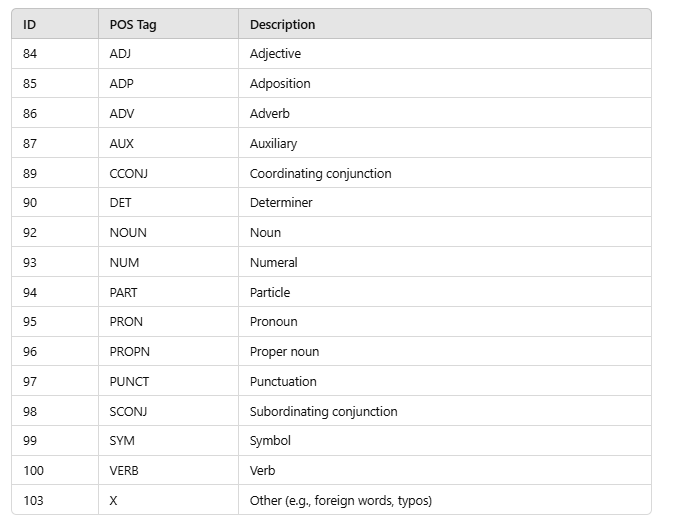

In [56]:
doc.vocab[96].text

'PROPN'

In [57]:
count.items()

dict_items([(96, 15), (92, 45), (100, 23), (90, 9), (85, 16), (93, 16), (97, 27), (98, 1), (84, 20), (103, 10), (87, 6), (99, 5), (89, 12), (86, 3), (94, 3), (95, 2)])

In [58]:
for k,v in count.items():
    print(doc.vocab[k].text, "|",v)

PROPN | 15
NOUN | 45
VERB | 23
DET | 9
ADP | 16
NUM | 16
PUNCT | 27
SCONJ | 1
ADJ | 20
SPACE | 10
AUX | 6
SYM | 5
CCONJ | 12
ADV | 3
PART | 3
PRON | 2


##apply pos using ntlk not spacy

In [59]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

text = "The quick brown fox jumps over the lazy dog."

# Tokenize the text into individual words
words = nltk.word_tokenize(text)

# Perform POS tagging on the tokenized words
pos_tags = nltk.pos_tag(words)

# Print the POS tags for each word
for word, tag in pos_tags:
    print(word, tag)

The DT
quick JJ
brown NN
fox NN
jumps VBZ
over IN
the DT
lazy JJ
dog NN
. .


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


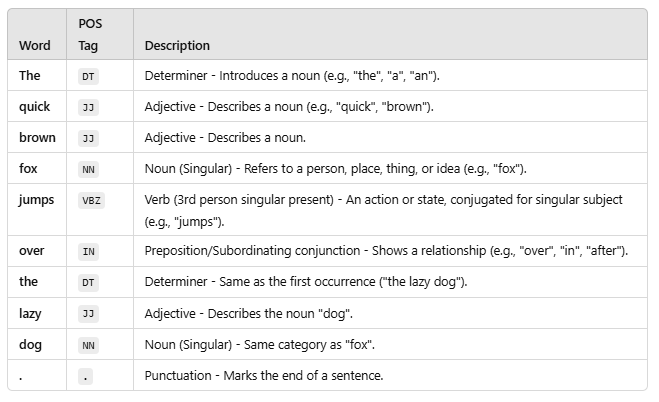

#Named Entity Recognition

In [60]:
import spacy
nlp = spacy.load("en_core_web_sm")

# en_core_web_sm >>> small model
# en_core_web_md >>> meduim model
# en_core_web_lg >>> large model

In [61]:
nlp.pipe_names
#the tasks which it will do

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

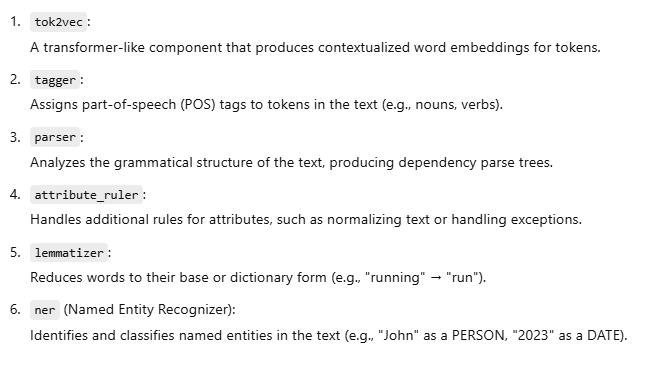

In [62]:
doc1 = nlp("Tesla Inc is going to acquire twitter for $45 billion")

for ent in doc.ents:
    print(ent.text, " | ", ent.label_, " | ", spacy.explain(ent.label_))

Microsoft Corp.  |  ORG  |  Companies, agencies, institutions, etc.
today  |  DATE  |  Absolute or relative dates or periods
the quarter ended December 31, 2021  |  DATE  |  Absolute or relative dates or periods
last fiscal year  |  DATE  |  Absolute or relative dates or periods
$51.7 billion  |  MONEY  |  Monetary values, including unit
20%  |  PERCENT  |  Percentage, including "%"
$22.2 billion  |  MONEY  |  Monetary values, including unit
24%  |  PERCENT  |  Percentage, including "%"
$18.8 billion  |  MONEY  |  Monetary values, including unit
21%  |  PERCENT  |  Percentage, including "%"
2.48  |  MONEY  |  Monetary values, including unit
22%  |  PERCENT  |  Percentage, including "%"
Digital  |  ORG  |  Companies, agencies, institutions, etc.
Satya Nadella  |  PERSON  |  People, including fictional
Microsoft  |  ORG  |  Companies, agencies, institutions, etc.
Microsoft Cloud  |  ORG  |  Companies, agencies, institutions, etc.
$22.1 billion  |  MONEY  |  Monetary values, including uni

In [63]:
from spacy import displacy#The displacy.render function with style="ent" is used to visually render Named Entity

displacy.render(doc1, style="ent")

# https://onecompiler.com/html/3zec3j8sc  >>> to show the result

In [64]:
##List down all the entities
nlp.pipe_labels['ner']

['CARDINAL',
 'DATE',
 'EVENT',
 'FAC',
 'GPE',
 'LANGUAGE',
 'LAW',
 'LOC',
 'MONEY',
 'NORP',
 'ORDINAL',
 'ORG',
 'PERCENT',
 'PERSON',
 'PRODUCT',
 'QUANTITY',
 'TIME',
 'WORK_OF_ART']

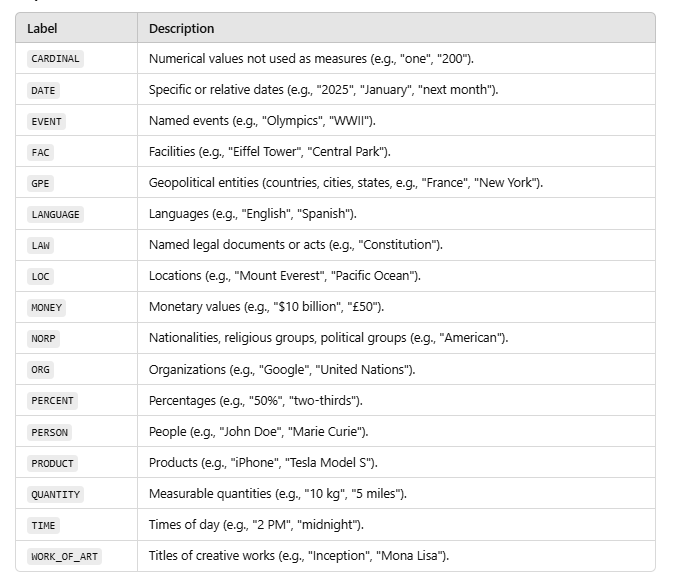

In [65]:
doc = nlp("Tesla Inc is going to acquire Twitter Inc for $45 billion")
for ent in doc.ents:
    print(ent.text, " | ", ent.label_, " | ", ent.start_char, "|", ent.end_char)

Tesla Inc  |  ORG  |  0 | 9
Twitter Inc  |  PERSON  |  30 | 41
$45 billion  |  MONEY  |  46 | 57


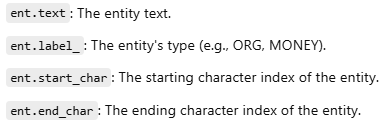

In [66]:
#Setting custom entities
doc = nlp("Tesla is going to acquire Twitter for $45 billion")
for ent in doc.ents:
    print(ent.text, " | ", ent.label_)


#here, when we deleted inc after twitter, the result was twiiter is product and that uncorrect so i need to handle in manually

Tesla  |  ORG
Twitter  |  PERSON
$45 billion  |  MONEY


In [67]:
s = doc[2:5]
s

going to acquire

In [68]:
type(s)

spacy.tokens.span.Span

In [69]:
from spacy.tokens import Span#method to add or modify entities in the document while preserving unmodified entities

s1 = Span(doc, 0, 1, label="ORG")
s2 = Span(doc, 5, 6, label="ORG")

doc.set_ents([s1, s2], default="unmodified")
# save the changes in s1,s2 without modification in others indices

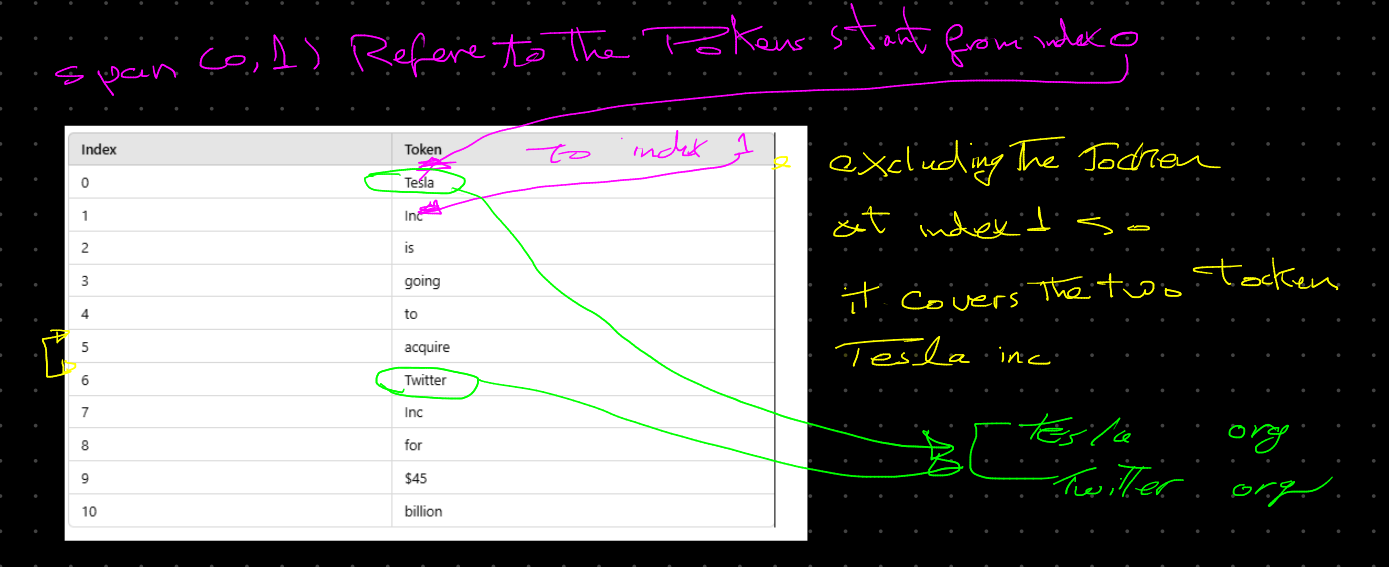

In [70]:
for ent in doc.ents:
    print(ent.text, " | ", ent.label_)

Tesla  |  ORG
Twitter  |  ORG
$45 billion  |  MONEY


##using NLTK


1- ne_chunk >>> responsible for NER IN NLTK which take tags as an input

In [71]:
import nltk
nltk.download('maxent_ne_chunker')#This model is a pre-trained classifier that identifies named entities (such as people, organizations, locations, etc.) in text.
nltk.download('words')
from nltk import word_tokenize, pos_tag, ne_chunk

# Define input text
input_text = "Steve Jobs was the CEO of Apple Corp. in California."

# Tokenize input text
tokens = word_tokenize(input_text)

# Perform Part-of-Speech (POS) tagging
pos_tags = pos_tag(tokens)
print('-'*10)
print('pos_tags',pos_tags)
print('-'*100)#The '*' operator in Python repeats the string (in this case, the hyphen '-') 100 times,

# Perform Named Entity Recognition (NER)
ne_tree = ne_chunk(pos_tags)# function in NLTK generates a syntactic tree, with named entities grouped under the NE label.
print('ne_tree',ne_tree)

----------
pos_tags [('Steve', 'NNP'), ('Jobs', 'NNP'), ('was', 'VBD'), ('the', 'DT'), ('CEO', 'NNP'), ('of', 'IN'), ('Apple', 'NNP'), ('Corp.', 'NNP'), ('in', 'IN'), ('California', 'NNP'), ('.', '.')]
----------------------------------------------------------------------------------------------------
ne_tree (S
  (PERSON Steve/NNP)
  (PERSON Jobs/NNP)
  was/VBD
  the/DT
  (ORGANIZATION CEO/NNP)
  of/IN
  (ORGANIZATION Apple/NNP Corp./NNP)
  in/IN
  (GPE California/NNP)
  ./.)


[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


In [72]:
# Extract named entities and their labels
named_entities = []
for subtree in ne_tree.subtrees():
    if subtree.label() in ['PERSON', 'ORGANIZATION', 'LOCATION']:
        named_entity = ' '.join(word for word, tag in subtree.leaves())
        print(named_entity)
        named_entities.append((named_entity, subtree.label()))

# Print named entities and their labels
print(named_entities)

Steve
Jobs
CEO
Apple Corp.
[('Steve', 'PERSON'), ('Jobs', 'PERSON'), ('CEO', 'ORGANIZATION'), ('Apple Corp.', 'ORGANIZATION')]


In [73]:
for word, tag in subtree.leaves():
    print(word)

California


#spell correction

1- using spellchecker()

2- using textblob()

In [74]:
from textblob import TextBlob

# Create a TextBlob object with the text to correct
text = "I havv a goood speling!"

# Create a new TextBlob object with corrected spelling
corrected_text = TextBlob(text).correct()

# Print the corrected text
print(corrected_text)

I have a good spelling!


#BOW(Bag of words)

In [75]:
paragraph =  """I have three visions for India. In 3000 years of our history, people from all over
               the world have come and invaded us, captured our lands, conquered our minds.
               From Alexander onwards, the Greeks, the Turks, the Moguls, the Portuguese, the British,
               the French, the Dutch, all of them came and looted us, took over what was ours.
               Yet we have not done this to any other nation. We have not conquered anyone.
               We have not grabbed their land, their culture,
               their history and tried to enforce our way of life on them.
               Why? Because we respect the freedom of others.That is why my
               first vision is that of freedom. I believe that India got its first vision of
               this in 1857, when we started the War of Independence. It is this freedom that
               we must protect and nurture and build on. If we are not free, no one will respect us.
               My second vision for India’s development. For fifty years we have been a developing nation.
               It is time we see ourselves as a developed nation. We are among the top 5 nations of the world
               in terms of GDP. We have a 10 percent growth rate in most areas. Our poverty levels are falling.
               Our achievements are being globally recognised today. Yet we lack the self-confidence to
               see ourselves as a developed nation, self-reliant and self-assured. Isn’t this incorrect?
               I have a third vision. India must stand up to the world. Because I believe that unless India
               stands up to the world, no one will respect us. Only strength respects strength. We must be
               strong not only as a military power but also as an economic power. Both must go hand-in-hand.
               My good fortune was to have worked with three great minds. Dr. Vikram Sarabhai of the Dept. of
               space, Professor Satish Dhawan, who succeeded him and Dr. Brahm Prakash, father of nuclear material.
               I was lucky to have worked with all three of them closely and consider this the great opportunity of my life.
               I see four milestones in my career"""

In [76]:
import re
import nltk


nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Test\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [77]:
# Cleaning the texts

stemmer = PorterStemmer()

lemitizer=WordNetLemmatizer()

sentences = nltk.sent_tokenize(paragraph) #split the paragraph to individual sentences based on spaces.

corpus = []

for i in range(len(sentences)): ##loop for each sentences individually

    review = re.sub('[^a-zA-Z]', ' ', sentences[i]) #replace any thing othwerwise characters with space
    review = review.lower()
    review = review.split()
    #review = [stemmer.stem(word) for word in review if not word in set(stopwords.words('english'))] #bad result
    review = [lemitizer.lemmatize(word) for word in review if not word in set(stopwords.words('english'))]
    review = ' '.join(review)
    corpus.append(review)
print(len(corpus))
corpus

31


['three vision india',
 'year history people world come invaded u captured land conquered mind',
 'alexander onwards greek turk mogul portuguese british french dutch came looted u took',
 'yet done nation',
 'conquered anyone',
 'grabbed land culture history tried enforce way life',
 '',
 'respect freedom others first vision freedom',
 'believe india got first vision started war independence',
 'freedom must protect nurture build',
 'free one respect u',
 'second vision india development',
 'fifty year developing nation',
 'time see developed nation',
 'among top nation world term gdp',
 'percent growth rate area',
 'poverty level falling',
 'achievement globally recognised today',
 'yet lack self confidence see developed nation self reliant self assured',
 'incorrect',
 'third vision',
 'india must stand world',
 'believe unless india stand world one respect u',
 'strength respect strength',
 'must strong military power also economic power',
 'must go hand hand',
 'good fortune worked

In [78]:
# # Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
x = cv.fit_transform(corpus)
x

# #but x is still in sparse matrix shape

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 155 stored elements and shape (31, 114)>

In [79]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
x = cv.fit_transform(corpus).toarray()
print(x.shape)
x
#so we have 114 unique words

(31, 114)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 1, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(31, 114))

#N-GRAM

##UNi-GRAM

In [80]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()
v.fit(["Thor Hathodawala is looking for ajob"])
v.vocabulary_

# give each word individually and it's index as a column
# by default(one gram)
# using fit function not fit_transform

{'thor': 5, 'hathodawala': 2, 'is': 3, 'looking': 4, 'for': 1, 'ajob': 0}

In [81]:
v = CountVectorizer(ngram_range=(1,1))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 5, 'hathodawala': 1, 'is': 2, 'looking': 4, 'for': 0, 'job': 3}

## BI-GRAM

In [82]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 9,
 'hathodawala': 2,
 'is': 4,
 'looking': 7,
 'for': 0,
 'job': 6,
 'thor hathodawala': 10,
 'hathodawala is': 3,
 'is looking': 5,
 'looking for': 8,
 'for job': 1}

In [83]:
v = CountVectorizer(ngram_range=(1,3))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 12,
 'hathodawala': 2,
 'is': 5,
 'looking': 9,
 'for': 0,
 'job': 8,
 'thor hathodawala': 13,
 'hathodawala is': 3,
 'is looking': 6,
 'looking for': 10,
 'for job': 1,
 'thor hathodawala is': 14,
 'hathodawala is looking': 4,
 'is looking for': 7,
 'looking for job': 11}

##Task :

1- remove stop words

2- lemmatize the text

3- apply n-gram

In [84]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

In [85]:
import spacy

# load english language model
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
    # remove stop words and lemmatize the text
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)

In [86]:
preprocess("Thor ate pizza")


'thor eat pizza'

In [87]:
preprocess("Loki is eating pizza")


'Loki eat pizza'

In [88]:
corpus_processed = [
    preprocess(text) for text in corpus
]
corpus_processed

['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [89]:
v = CountVectorizer(ngram_range=(1,2))
v.fit(corpus_processed)
v.vocabulary_

{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

In [90]:
# fit >>>> take all the documents.
# transform  >>> take sentence that you want to encode it.
v.transform(["Thor eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 1, 1]])

In [91]:
v.transform(["Hulk eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 0, 0]])

# TF-IDF

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [93]:
# Example documents
docs = [
  "The quick brown fox jumps over the lazy dog.",
  "A stitch in time saves nine.",
  "The early bird catches the worm.",
  "Actions speak louder than words.",
]

In [94]:
# Create a TF-IDF vectorizer instance
tfidf = TfidfVectorizer()

# Fit the vectorizer to the documents
tfidf.fit(docs)

# Transform the documents into a TF-IDF matrix
tfidf_matrix = tfidf.transform(docs)
print(tfidf_matrix.toarray())

# YOU CAN MAKE IT IN ONE LINE using fit_transform.

[[0.         0.         0.32467583 0.         0.32467583 0.
  0.32467583 0.         0.32467583 0.32467583 0.         0.
  0.32467583 0.32467583 0.         0.         0.         0.
  0.5119563  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.4472136  0.         0.         0.         0.4472136
  0.         0.         0.4472136  0.         0.4472136  0.
  0.         0.4472136  0.         0.        ]
 [0.         0.39264414 0.         0.39264414 0.         0.39264414
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.6191303  0.         0.         0.39264414]
 [0.4472136  0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.4472136  0.
  0.         0.         0.         0.4472136  0.         0.4472136
  0.         0.         0.4472136  0.        ]]


When sklearn.__version__ <= 0.24.x use following method

get_feature_names()


When sklearn.__version__ >= 1.0.x use following method

get_feature_names_out()

In [95]:
# Convert the matrix to a pandas dataframe
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# Display the dataframe
print(df_tfidf)


# will make every unique word as a feature, so because i have 22 columns.
# noticed, the most frequency word is the least value of TF-IDF

    actions      bird     brown   catches       dog     early       fox  \
0  0.000000  0.000000  0.324676  0.000000  0.324676  0.000000  0.324676   
1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2  0.000000  0.392644  0.000000  0.392644  0.000000  0.392644  0.000000   
3  0.447214  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

         in     jumps      lazy  ...      over     quick     saves     speak  \
0  0.000000  0.324676  0.324676  ...  0.324676  0.324676  0.000000  0.000000   
1  0.447214  0.000000  0.000000  ...  0.000000  0.000000  0.447214  0.000000   
2  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.000000   
3  0.000000  0.000000  0.000000  ...  0.000000  0.000000  0.000000  0.447214   

     stitch      than       the      time     words      worm  
0  0.000000  0.000000  0.511956  0.000000  0.000000  0.000000  
1  0.447214  0.000000  0.000000  0.447214  0.000000  0.000000  
2  0.000000  0.000000  0.619130

## the numbers of uniques words(min_df)

1- min_df>>>>>>> will control the numbers of words which will be appeared based on numbers of frequency

In [96]:
#the default of min_df is one
doc1 = "the quick brown fox"
doc2 = "the lazy dog"
doc3 = "the quick brown cat"

cv = TfidfVectorizer()
X = cv.fit_transform([doc1, doc2, doc3])
print(cv.get_feature_names_out())  # ['brown', 'cat', 'dog', 'fox', 'lazy', 'quick', 'the']
print(X.toarray())

['brown' 'cat' 'dog' 'fox' 'lazy' 'quick' 'the']
[[0.4804584  0.         0.         0.63174505 0.         0.4804584
  0.37311881]
 [0.         0.         0.65249088 0.         0.65249088 0.
  0.38537163]
 [0.4804584  0.63174505 0.         0.         0.         0.4804584
  0.37311881]]


In [97]:
cv = TfidfVectorizer(min_df=2)
X = cv.fit_transform([doc1, doc2, doc3])
print(cv.get_feature_names_out())  # ['brown', 'quick', 'the']
print(X.toarray())

#noticed thatcat,dog,fox,lazy]>>>>>> not appeared becuse the numbers of repeats less than two

['brown' 'quick' 'the']
[[0.61980538 0.61980538 0.48133417]
 [0.         0.         1.        ]
 [0.61980538 0.61980538 0.48133417]]


In [98]:
cv = TfidfVectorizer(min_df=2,stop_words='english')
X = cv.fit_transform([doc1, doc2, doc3])
print(cv.get_feature_names_out())  # ['brown', 'quick', 'the']
print(X.toarray())

#noticed that [the]>>>>>>>>not appeared becuse it is from stop_word

['brown' 'quick']
[[0.70710678 0.70710678]
 [0.         0.        ]
 [0.70710678 0.70710678]]


##Another Example

In [99]:
text=["Hi How are you How are you doing","Hi what's up","Wow that's awesome"]
cv = TfidfVectorizer(min_df=1)
x_traincv = cv.fit_transform(text)
feature_names = cv.get_feature_names_out()

# Print the feature names and the TF-IDF matrix
print(feature_names)
print(x_traincv.toarray())

['are' 'awesome' 'doing' 'hi' 'how' 'that' 'up' 'what' 'wow' 'you']
[[0.54275734 0.         0.27137867 0.20639047 0.54275734 0.
  0.         0.         0.         0.54275734]
 [0.         0.         0.         0.4736296  0.         0.
  0.62276601 0.62276601 0.         0.        ]
 [0.         0.57735027 0.         0.         0.         0.57735027
  0.         0.         0.57735027 0.        ]]


In [100]:
#Another Example

text=["Hi How are you How are you doing","Hi what's up","Wow that's awesome"]
cv = TfidfVectorizer(min_df=1,stop_words='english')
x_traincv = cv.fit_transform(text)
feature_names = cv.get_feature_names_out()

# Print the feature names and the TF-IDF matrix
print(feature_names)
print(x_traincv.toarray())

['awesome' 'doing' 'hi' 'wow']
[[0.         0.79596054 0.60534851 0.        ]
 [0.         0.         1.         0.        ]
 [0.70710678 0.         0.         0.70710678]]


# Word Embedding

### Word Embedding Techniques using Embedding Layer in Keras

In [101]:
### Libraries USed Tensorflow> 2.0  and keras

In [116]:
##tensorflow >2.0
from tensorflow.keras.preprocessing.text import one_hot

In [103]:
### sentences
sents=[  'the glass of milk',
     'the glass of juice',
     'the cup of tea',
    'I am a good boy',
     'I am a good developer',
     'understand the meaning of words',
     'your videos are good',]

In [104]:
sents

['the glass of milk',
 'the glass of juice',
 'the cup of tea',
 'I am a good boy',
 'I am a good developer',
 'understand the meaning of words',
 'your videos are good']

1-  In general, a larger vocabulary size allows for a more nuanced representation of the language, but it also increases the computational cost of training the embedding model. On the other hand, a smaller vocabulary size may limit the expressiveness of the embeddings and reduce the accuracy of the trained model.

2- A reasonable starting point for a vocabulary size is around 20,000 to 30,000, but this may need to be adjusted up or down depending on your specific use case. If you have a smaller dataset or are working with a less complex language, you may be able to use a smaller vocabulary size

In [105]:
### Vocabulary size>>>> the size of unique words
voc_size=10000

#### One Hot Representation

In [118]:
#will make one hot encoding and return each sentence with it's indices

onehot_repr=[one_hot(sent,voc_size)for sent in sents]
print(onehot_repr)

#indices of the words in the sentences, and each word will have a unique id based on the vocabulary size.
#[2725, 4751, 1322, 7778] >>>>>the glass of milk(the numbers of indices of the words)

[[6313, 3878, 7528, 4040], [6313, 3878, 7528, 9788], [6313, 9758, 7528, 4529], [5249, 723, 5984, 9839, 3809], [5249, 723, 5984, 9839, 3085], [4768, 6313, 9316, 7528, 2257], [8138, 5361, 3083, 9839]]


### Word Embedding Represntation

In [119]:
import numpy as np
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential

1- here, we will pass the result of one hot to embedding layer.

2- but not all the sentences have same numbers of words , so i will make padding.

3- padding='pre' or 'post'>>>> the zeros before or after indices to be same size.

4- The choice of padding can affect the performance of the model, depending on the nature of the data. For example, if the end of the sequence is more important for the task at hand, you may want to use padding='pre' to preserve the order of the original sequence. On the other hand, if the beginning of the sequence is more important, you may want to use padding='post'. In some cases, it may be useful to try both options and see which one works better for your particular task.

In [120]:
sent_length=8
embedded_docs=pad_sequences(onehot_repr,padding='pre',maxlen=sent_length)
print(embedded_docs)

# sent_length >>> maximum numbers of words in sentence

[[   0    0    0    0 6313 3878 7528 4040]
 [   0    0    0    0 6313 3878 7528 9788]
 [   0    0    0    0 6313 9758 7528 4529]
 [   0    0    0 5249  723 5984 9839 3809]
 [   0    0    0 5249  723 5984 9839 3085]
 [   0    0    0 4768 6313 9316 7528 2257]
 [   0    0    0    0 8138 5361 3083 9839]]


In [121]:
dim=10
# dim >>> maximum numbers of vectors to represent one word in sentence.

In [122]:
model = Sequential()
model.add(Embedding(voc_size,10,input_length=sent_length))
model.build(input_shape=(32, sent_length))  # batch_size=32
model.compile('adam','mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 8, 10)            │       100,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,000 (390.62 KB)

 Trainable params: 100,000 (390.62 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 8, 10)            │       100,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,000 (390.62 KB)

 Trainable params: 100,000 (390.62 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
print(model.predict(embedded_docs))
#there are the features would be used in the models

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
[[[ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974
   -0.03566261  0.04868939 -0.00715635 -0.04982267  0.00984567]
  [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974
   -0.03566261  0.04868939 -0.00715635 -0.04982267  0.00984567]
  [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974
   -0.03566261  0.04868939 -0.00715635 -0.04982267  0.00984567]
  [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974
   -0.03566261  0.04868939 -0.00715635 -0.04982267  0.00984567]
  [-0.041098   -0.0032081  -0.00217552 -0.00298419  0.02897078
    0.00067539 -0.02194852  0.00779381  0.00294435 -0.01524464]
  [-0.01698999 -0.00929324 -0.02941899  0.01779611  0.00997032
    0.04239111  0.03118876  0.02203301 -0.02157595 -0.034245  ]
  [ 0.03460565 -0.03263129 -0.00889411  0.03183982  0.01488301
   -0.04917799 -0.04400298 -0.02376987 -0.00407846  0.0427781 ]
  [-0.01502232 -0.00858364 -0.01847955 -0.02623783  0.03298766
    0.042

In [125]:
#frist sentence after onehot + padding
embedded_docs[0]

array([   0,    0,    0,    0, 6313, 3878, 7528, 4040], dtype=int32)

In [126]:
#frist sentence after embedding
print(model.predict(embedded_docs)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
[[ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [-0.041098   -0.0032081  -0.00217552 -0.00298419  0.02897078  0.00067539
  -0.02194852  0.00779381  0.00294435 -0.01524464]
 [-0.01698999 -0.00929324 -0.02941899  0.01779611  0.00997032  0.04239111
   0.03118876  0.02203301 -0.02157595 -0.034245  ]
 [ 0.03460565 -0.03263129 -0.00889411  0.03183982  0.01488301 -0.04917799
  -0.04400298 -0.02376987 -0.00407846  0.0427781 ]
 [-0.01502232 -0.00858364 -0.01847955 -0.02623783  0.03298766  0.04259482
   0.03893895

In [127]:
print(model.predict(embedded_docs)[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [ 0.02670727  0.04354355 -0.02828448  0.01799988  0.04753974 -0.03566261
   0.04868939 -0.00715635 -0.04982267  0.00984567]
 [-0.041098   -0.0032081  -0.00217552 -0.00298419  0.02897078  0.00067539
  -0.02194852  0.00779381  0.00294435 -0.01524464]
 [-0.01698999 -0.00929324 -0.02941899  0.01779611  0.00997032  0.04239111
   0.03118876  0.02203301 -0.02157595 -0.034245  ]
 [ 0.03460565 -0.03263129 -0.00889411  0.03183982  0.01488301 -0.04917799
  -0.04400298 -0.02376987 -0.00407846  0.0427781 ]
 [ 0.00159955 -0.03395136  0.01213584 -0.03783605  0.00760283 -0.01517892
   0.02102604